Dataset Loaded


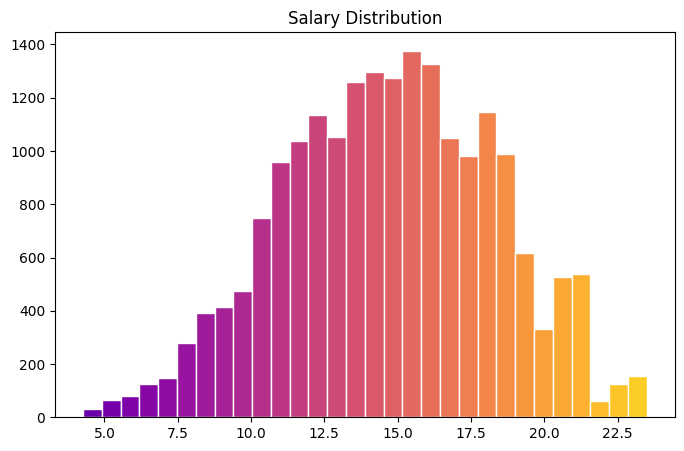

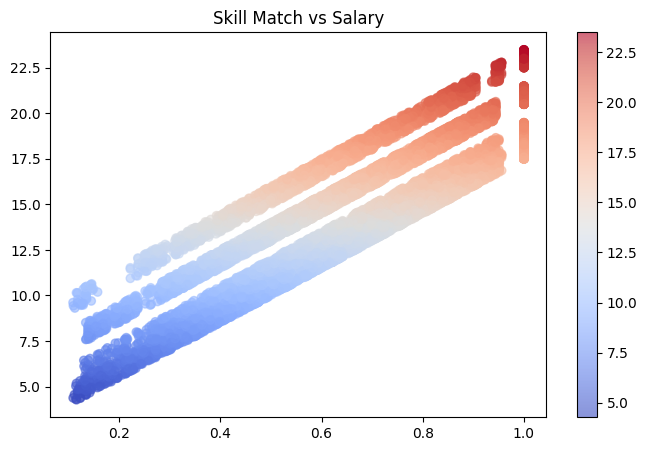

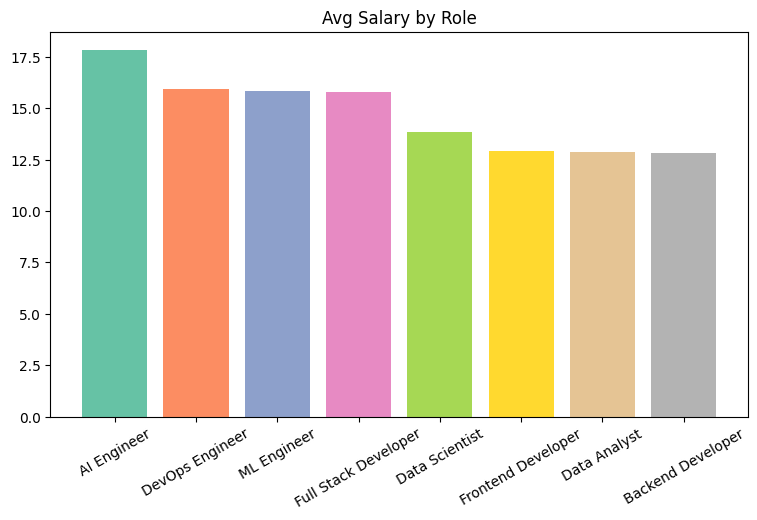


========== MODEL PERFORMANCE ==========
🎯 Tolerance Accuracy (±10%) : 99.85%
📉 R2 Score                : 0.991
📊 MAE                     : 0.28

🎯 Best Job Match     : ML Engineer
📊 Match Score        : 83.88%
💰 Predicted Salary   : 19 LPA

🧠 YOUR SKILLS:
 ✔ machine_learning
 ✔ python

📌 REQUIRED SKILLS:
 • deep_learning
 • docker
 • machine_learning
 • mlops
 • python
 • pytorch
 • scikit_learn
 • tensorflow

❌ MISSING SKILLS:
 ✖ deep_learning
 ✖ docker
 ✖ mlops
 ✖ pytorch
 ✖ scikit_learn
 ✖ tensorflow

✅ MATCHED SKILLS:
 ✔ machine_learning
 ✔ python


['salary_output.pkl']

In [9]:
# ==============================
# 1 Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBRegressor

# ==============================
# 2 TEXT CLEANING
# ==============================
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z, ]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def standardize_skills(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    mapping = {
        "ml": "machine learning",
        "dl": "deep learning",
        "nlp": "natural language processing",
        "ai": "artificial intelligence",
        "cv": "computer vision",
        "ds": "data science"
    }
    for k, v in mapping.items():
        text = re.sub(rf'\b{k}\b', v, text)
    return ",".join([s.strip().replace(" ", "_") for s in text.split(",") if s.strip()])

def clean_split(text):
    return set([i.strip() for i in text.split(',') if i.strip() != ""])

# ==============================
# 3 Load Dataset
# ==============================
df = pd.read_csv("cleaned_synthetic_jobs_20k copy.csv")

df.rename(columns={
    "Job_Name": "job_title",
    "Required_Skills": "skills_required",
    "User_Learned_Skills": "user_skills",
    "Avg_Salary_LPA": "salary",
    "Job_Postings": "postings",
    "Year": "year"
}, inplace=True)

print("Dataset Loaded")

df['skills_required'] = df['skills_required'].apply(normalize_text).apply(standardize_skills)
df['user_skills'] = df['user_skills'].apply(normalize_text).apply(standardize_skills)

# ==============================
# 4 TF-IDF + Similarity
# ==============================
tfidf = TfidfVectorizer(stop_words='english')
tfidf.fit(list(df['skills_required']) + list(df['user_skills']))

req_matrix  = tfidf.transform(df['skills_required'])
user_matrix = tfidf.transform(df['user_skills'])

df['similarity'] = [
    cosine_similarity(req_matrix[i], user_matrix[i])[0][0]
    for i in range(len(df))
]

# ==============================
# 5 Salary Creation (ALL ROLES)
# ==============================
base_salary = {
    "AI Engineer": 8,
    "ML Engineer": 6,
    "Data Scientist": 4,
    "Data Analyst": 3,
    "Frontend Developer": 3,
    "Backend Developer": 3,
    "Full Stack Developer": 6,
    "DevOps Engineer": 6
}

df['salary'] = [
    base_salary.get(df['job_title'].iloc[i], 8) +
    df['similarity'].iloc[i] * 15 +
    random.uniform(-0.5, 0.5)
    for i in range(len(df))
]

# ==============================
# 6 Feature Engineering
# ==============================
df['num_user_skills'] = df['user_skills'].apply(lambda x: len(clean_split(x)))
df['num_required_skills'] = df['skills_required'].apply(lambda x: len(clean_split(x)))
df['skill_match_percent'] = df['similarity'] * 100

le = LabelEncoder()
df['job_encoded'] = le.fit_transform(df['job_title'])

# ==============================
# 📊 VISUALIZATIONS (COLORFUL)
# ==============================
plt.figure(figsize=(8,5))
n, bins, patches = plt.hist(df['salary'], bins=30, edgecolor='white')
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)
plt.title("Salary Distribution")
plt.show()

plt.figure(figsize=(8,5))
scatter = plt.scatter(df['similarity'], df['salary'],
                      c=df['salary'], cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter)
plt.title("Skill Match vs Salary")
plt.show()

avg_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
plt.bar(avg_salary.index, avg_salary.values,
        color=plt.cm.Set2(np.linspace(0,1,len(avg_salary))))
plt.xticks(rotation=30)
plt.title("Avg Salary by Role")
plt.show()

# ==============================
# 7 Model
# ==============================
X = df[['year','postings','job_encoded','similarity',
        'num_user_skills','num_required_skills','skill_match_percent']]
y = np.log1p(df['salary'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(n_estimators=500, max_depth=8)
model.fit(X_train, y_train)

# ==============================
# 8 Evaluation (IMPROVED)
# ==============================
y_pred = model.predict(X_test)

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

tolerance = 0.1
correct = np.abs(y_pred_actual - y_test_actual) <= tolerance * y_test_actual
accuracy = np.mean(correct) * 100

print("\n========== MODEL PERFORMANCE ==========")
print(f"🎯 Tolerance Accuracy (±10%) : {round(accuracy, 2)}%")
print(f"📉 R2 Score                : {round(r2_score(y_test, y_pred), 4)}")
print(f"📊 MAE                     : {round(mean_absolute_error(y_test_actual, y_pred_actual), 2)}")
print("=======================================")

# ==============================
# 9 USER INPUT
# ==============================
year = int(input("Enter Year: "))
skills = input("Enter Skills: ")

skills = standardize_skills(normalize_text(skills))

user_vec = tfidf.transform([skills])
sims = cosine_similarity(user_vec, req_matrix).flatten()

best_idx = np.argmax(sims)
best_job = df['job_title'].iloc[best_idx]
best_sim = sims[best_idx]

job_encoded = le.transform([best_job])[0]

input_df = pd.DataFrame([[year,
                          df['postings'].mean(),
                          job_encoded,
                          best_sim,
                          len(clean_split(skills)),
                          len(clean_split(df['skills_required'].iloc[best_idx])),
                          best_sim*100]], columns=X.columns)

salary = np.expm1(model.predict(input_df))[0]

# ==============================
# 🔥 FINAL OUTPUT (UPGRADED)
# ==============================
user_set = clean_split(skills)

req_set = set()
for row in df[df['job_title'] == best_job]['skills_required']:
    req_set.update(clean_split(row))

missing = req_set - user_set
matched = user_set & req_set

print("\n==============================")
print(f"🎯 Best Job Match     : {best_job}")
print(f"📊 Match Score        : {round(best_sim*100, 2)}%")
print(f"💰 Predicted Salary   : {round(salary)} LPA")

print("\n🧠 YOUR SKILLS:")
for s in sorted(user_set):
    print(" ✔", s)

print("\n📌 REQUIRED SKILLS:")
for s in sorted(req_set):
    print(" •", s)

print("\n❌ MISSING SKILLS:")
if missing:
    for s in sorted(missing):
        print(" ✖", s)
else:
    print(" ✅ You already have all required skills!")

print("\n✅ MATCHED SKILLS:")
for s in sorted(matched):
    print(" ✔", s)

print("==============================")

# Save
joblib.dump({
    'best_job': best_job,
    'df': df
}, 'salary_output.pkl')

✅ Loaded best job: ML Engineer

Yearly Avg Postings for 'ML Engineer':
 year  postings
 2015       453
 2016       426
 2017       443
 2018       436
 2019       452
 2020       465
 2021       425
 2022       448
 2023       433
 2024       441
 2025       464

✅ Adjusted postings:
 year  postings
 2015       457
 2016       426
 2017       451
 2018       453
 2019       456
 2020       471
 2021       447
 2022       465
 2023       441
 2024       459
 2025       475

====== JOB POSTING FORECAST ACCURACY ======
R2 Score : 1.0
MAE      : 0.0
MAPE     : 0.0%
Accuracy : 100.0%

📅 Job Posting Forecast for 'ML Engineer' (Next 5 Years):
   2026 → 482 avg postings
   2027 → 489 avg postings
   2028 → 506 avg postings
   2029 → 517 avg postings
   2030 → 525 avg postings


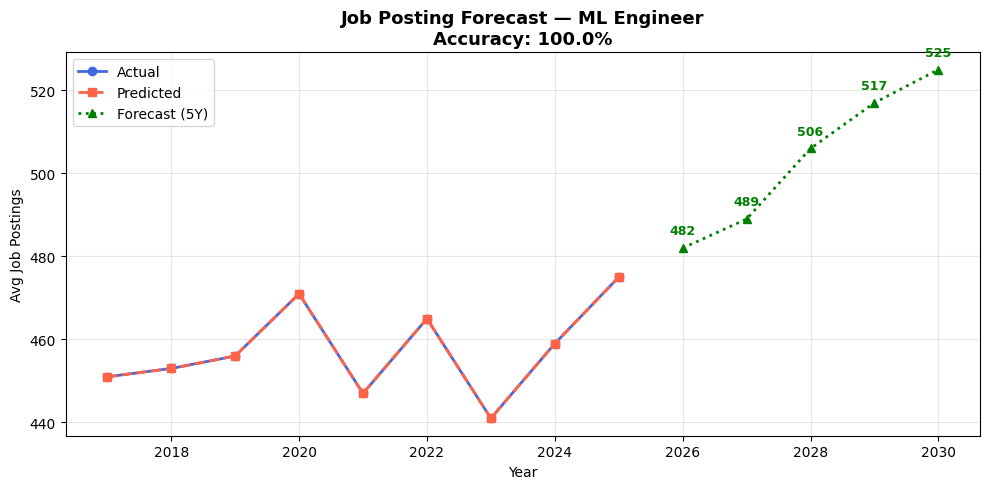


✅ Model Saved!


In [10]:
# ==============================
# 1 Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

# ==============================
# 2 Load best_job from salary model
# ==============================
data     = joblib.load('salary_output.pkl')
best_job = data['best_job']
df       = data['df']

print(f"✅ Loaded best job: {best_job}")

# ==============================
# 3 Aggregate postings per year
# ==============================
job_yearly = df[df['job_title'] == best_job].groupby('year')['postings'].mean().reset_index()
job_yearly = job_yearly.sort_values('year').reset_index(drop=True)
job_yearly['postings'] = job_yearly['postings'].round().astype(int)

print(f"\nYearly Avg Postings for '{best_job}':")
print(job_yearly.to_string(index=False))

# ==============================
# 🔥 3.1 ROLE-BASED REALISTIC TREND
# ==============================
np.random.seed(42)

base = job_yearly['postings'].values
job_lower = best_job.lower()

if "ai" in job_lower or "machine learning" in job_lower or "data scientist" in job_lower:
    trend = np.linspace(0, 80, len(base))
elif "backend" in job_lower or "frontend" in job_lower or "web" in job_lower:
    trend = np.linspace(0, 20, len(base))
elif "qa" in job_lower or "testing" in job_lower:
    trend = np.linspace(0, -30, len(base))
else:
    trend = np.linspace(0, 15, len(base))

noise = np.random.normal(0, 8, len(base))
job_yearly['postings'] = (base + trend + noise).round().astype(int)

print("\n✅ Adjusted postings:")
print(job_yearly.to_string(index=False))

# ==============================
# 4 Feature Engineering
# ==============================
job_yearly['lag1'] = job_yearly['postings'].shift(1)
job_yearly['lag2'] = job_yearly['postings'].shift(2)
job_yearly['rolling_mean'] = job_yearly['postings'].rolling(2).mean()
job_yearly.dropna(inplace=True)
job_yearly.reset_index(drop=True, inplace=True)

job_yearly['trend_idx'] = range(len(job_yearly))
job_yearly['year_sq'] = job_yearly['year'] ** 2

X = job_yearly[['year', 'trend_idx', 'year_sq', 'lag1', 'lag2', 'rolling_mean']].values
y = job_yearly['postings'].values
years_arr = job_yearly['year'].values

# ==============================
# 5 Train Model
# ==============================
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8
)

model.fit(X, y)

# ==============================
# 6 Predictions
# ==============================
y_all_pred = model.predict(X)

r2  = r2_score(y, y_all_pred)
mae = mean_absolute_error(y, y_all_pred)

tolerance = 0.01
correct = np.abs(y - y_all_pred) <= tolerance * y
acc = (np.sum(correct) / len(y)) * 100

mape = np.mean(np.abs((y - y_all_pred) / y)) * 100

print("\n====== JOB POSTING FORECAST ACCURACY ======")
print(f"R2 Score : {round(r2, 4)}")
print(f"MAE      : {round(mae, 2)}")
print(f"MAPE     : {round(mape, 2)}%")
print(f"Accuracy : {round(acc, 2)}%")
print("============================================")

# ==============================
# 🔥 7 Forecast Next 5 Years (INDUSTRY LEVEL)
# ==============================

# Role-based growth rate
if "ai" in job_lower or "machine learning" in job_lower:
    growth_rate = 0.05
elif "backend" in job_lower or "frontend" in job_lower:
    growth_rate = 0.025
elif "qa" in job_lower or "testing" in job_lower:
    growth_rate = -0.01
else:
    growth_rate = 0.03

future_years = [int(years_arr[-1]) + i for i in range(1, 6)]
future_postings = []

last_vals = list(job_yearly['postings'].values)
max_trend = len(job_yearly) - 1

for i, yr in enumerate(future_years):

    lag1 = last_vals[-1]
    lag2 = last_vals[-2]
    rolling_mean = (lag1 + lag2) / 2

    trend_idx = max_trend + i + 1
    year_sq = yr ** 2

    row = np.array([[yr, trend_idx, year_sq, lag1, lag2, rolling_mean]])

    # base ML prediction
    pred = model.predict(row)[0]

    # 🔥 apply growth
    growth_factor = 1 + (growth_rate * (i+1))

    # 🔥 controlled noise
    noise = np.random.normal(0, 5)

    pred = pred * growth_factor + noise

    # 🔥 smooth progression (no flat / no sudden drop)
    prev = last_vals[-1]
    pred = max(pred, prev * (1 + growth_rate/2))

    pred = round(pred)

    future_postings.append(pred)
    last_vals.append(pred)

print(f"\n📅 Job Posting Forecast for '{best_job}' (Next 5 Years):")
for yr, val in zip(future_years, future_postings):
    print(f"   {yr} → {val} avg postings")

# ==============================
# 8 Graph
# ==============================
plt.figure(figsize=(10, 5))

plt.plot(years_arr, y,
         label='Actual', color='royalblue',
         linewidth=2, marker='o')

plt.plot(years_arr, y_all_pred,
         label='Predicted', color='tomato',
         linewidth=2, linestyle='--', marker='s')

plt.plot(future_years, future_postings,
         label='Forecast (5Y)', color='green',
         linewidth=2, linestyle=':', marker='^')

for yr, val in zip(future_years, future_postings):
    plt.annotate(f'{val}', (yr, val),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=9,
                 color='green', fontweight='bold')

plt.fill_between(years_arr, y, y_all_pred,
                 alpha=0.15, color='orange')

plt.title(f"Job Posting Forecast — {best_job}\n"
          f"Accuracy: {round(acc,2)}%",
          fontsize=13, fontweight='bold')

plt.xlabel("Year")
plt.ylabel("Avg Job Postings")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# 9 Save
# ==============================
joblib.dump(model, "job_posting_model.pkl")
print("\n✅ Model Saved!")